# Computer Vision (AI-4002): Geometric Transformations + Lab 04 (Feature Extraction)
Every code snippet from the **Geometric Transformations notebook** and the **Lab 04 manual**, in one runnable file. Each section has: a short explanation, the code with comments, and a **🎯 When you'd use this** note.

**Before you start**
- Put `image.jpg` next to this notebook (the manuals use that name). If it is missing, a synthetic demo image is generated so every cell still runs.
- Cells marked **Manual version** are the lab's code as written. Where the manual's code has a bug or a mismatch, the cell right after it shows a **Fixed version** and says what was wrong. I tested each of these.
- Lab 01 (reading, grayscale, resize, blur, crop, text, threshold, rotation, blending, histogram equalization) is in the earlier `CV_Lab01_Cheatsheet.ipynb`.

| Part A: Geometric transformations | Part B: Lab 04 |
|---|---|
| A1 Translation · A2 Rotation · A3 Scaling · A4 Shear · A5 Rigid · A6 Perspective · A7 Affine from 3 points | B1 HOG · B2 LBP · B3 Colour histogram · B4 HED · B5 HIG · B6 Texture energy/contrast · B7 Material-classification task · B8 Filtering · B9 Convolution types · B10 Edge detection · B11 Canny |

In [30]:
import os, math
import cv2
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.dpi'] = 70      # keeps inline figures (and the .ipynb file) small
print("OpenCV:", cv2.__version__, "| NumPy:", np.__version__)

IMAGE_PATH = 'image.jpg'             # <- change if your file has another name

OpenCV: 5.0.0 | NumPy: 2.3.5


Image size: 2598 x 4077 (width x height)


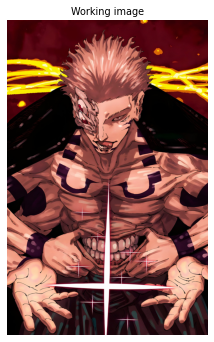

In [31]:
# ---------------- helpers (used by every section) ----------------
def make_demo_image(h=480, w=480):
    # Synthetic building scene (edges, corners, windows, a textured ground) used when image.jpg is missing.
    img = np.zeros((h, w, 3), np.uint8)
    for y in range(h):                                               # sky gradient (BGR)
        img[y, :] = (255 - int(40 * y / h), 245 - int(25 * y / h), 235)
    cv2.rectangle(img, (60, 180), (420, 400), (170, 90, 30), -1)     # walls
    cv2.fillPoly(img, [np.array([[40, 180], [240, 80], [440, 180]])], (140, 60, 10))   # roof
    for r in range(3):                                               # windows
        for c in range(6):
            x, y = 80 + c * 55, 205 + r * 60
            cv2.rectangle(img, (x, y), (x + 35, y + 40), (240, 230, 200), -1)
            cv2.rectangle(img, (x, y), (x + 35, y + 40), (90, 40, 10), 2)
    cv2.rectangle(img, (215, 340), (265, 400), (60, 30, 5), -1)      # door
    cv2.circle(img, (240, 140), 22, (240, 230, 200), -1)             # round window
    img[400:] = (120, 150, 120)                                      # grass
    noise = np.random.default_rng(0).normal(0, 18, (h - 400, w, 1))  # grass texture
    img[400:] = np.clip(img[400:] + noise, 0, 255)
    cv2.putText(img, 'HALL', (170, 450), cv2.FONT_HERSHEY_DUPLEX, 1.4, (255, 255, 255), 3, cv2.LINE_AA)
    return img

def load_image(path, flag=cv2.IMREAD_COLOR):
    # cv2.imread returns None (no error!) for a wrong path -> fall back to the demo image.
    img = cv2.imread(path, flag)
    if img is None:
        print(f"[!] '{path}' not found -> using the synthetic demo image")
        img = make_demo_image()
        if flag == cv2.IMREAD_GRAYSCALE:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    return img

def bgr2rgb(x): return cv2.cvtColor(x, cv2.COLOR_BGR2RGB)

def norm8(x):
    # scale any array (e.g. float gradients) to 0-255 uint8 so it can be displayed
    return cv2.normalize(x, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

def show(images, titles=None, cols=3, figsize=None):
    # Grid display. 3-channel images must already be RGB; 2-D arrays are shown as grayscale 0-255.
    images = images if isinstance(images, (list, tuple)) else [images]
    n = len(images); cols = min(cols, n); rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=figsize or (4.4 * cols, 4.4 * rows))
    for i, ax in enumerate(np.atleast_1d(axes).ravel()):
        ax.axis('off')
        if i < n:
            ax.imshow(images[i], cmap='gray', vmin=0, vmax=255) if images[i].ndim == 2 else ax.imshow(images[i])
            if titles: ax.set_title(titles[i], fontsize=10)
    plt.tight_layout(); plt.show()

image      = load_image(IMAGE_PATH)                   # BGR (OpenCV order)
image_rgb  = bgr2rgb(image)                           # RGB for Matplotlib
gray       = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)  # single channel
height, width = image.shape[:2]                       # shape = (rows, cols) = (height, width)
print("Image size:", width, "x", height, "(width x height)")
show([image_rgb], ['Working image'], cols=1, figsize=(5, 5))

---
# Part A: Geometric transformations
A geometric transformation moves pixels; it does not change their values. Every warp follows the same steps: **build a matrix → choose the output size `(width, height)` → apply `warpAffine` / `warpPerspective`**. Pixels that land outside the output canvas are cut off, and empty areas are filled with black.

| Transform | Matrix | Keeps parallel lines? | Keeps angles/lengths? |
|---|---|---|---|
| Translation, Rigid | 2×3 | yes | yes |
| Uniform scaling | 2×3 | yes | angles yes, lengths scaled |
| Non-uniform scaling, Shear, general Affine | 2×3 | yes | no |
| Perspective (projective) | 3×3 | **no** | no |

## A1. Translation
Shifts the image `tx` pixels right and `ty` pixels down. Matrix `[[1,0,tx],[0,1,ty]]`.

**🎯 When you'd use this:** aligning two shots of the same scene that are slightly offset; data augmentation (random shifts so a CNN doesn't depend on exact object position); moving an ROI to a canvas centre.

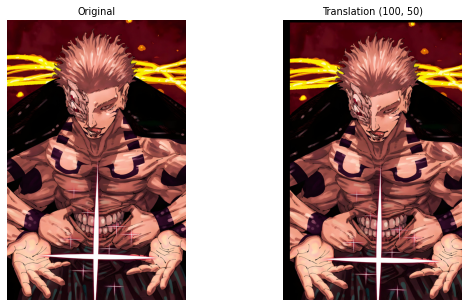

In [32]:
# Translation values: +tx moves RIGHT, +ty moves DOWN
tx, ty = 100, 50

# Translation matrix: identity in the 2x2 part, shift in the last column
M = np.float32([[1, 0, tx],
                [0, 1, ty]])

# warpAffine(src, M, dsize=(width, height)); same canvas size -> pixels shifted off the edge are lost
translated = cv2.warpAffine(image, M, (width, height))

show([image_rgb, bgr2rgb(translated)], ['Original', f'Translation ({tx}, {ty})'], cols=2, figsize=(9, 4.5))

## A2. Rotation
`getRotationMatrix2D(center, angle, scale)` builds the matrix. Internally it moves the centre to the origin, rotates, then moves back, so the image spins about `center`. **Positive angle = counter-clockwise.**

**🎯 When you'd use this:** straightening a tilted scan or phone photo of a document; rotation augmentation for training data; correcting a camera mounted at an angle.

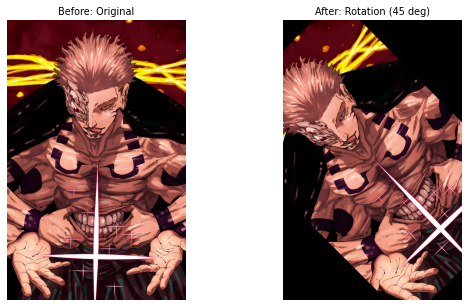

Rotation matrix:
 [[ 7.070000e-01  7.070000e-01 -1.060615e+03]
 [-7.070000e-01  7.070000e-01  1.515448e+03]]


In [33]:
center = (width // 2, height // 2)    # pivot as (x, y): OpenCV points are (x, y), NOT (row, col)
angle  = 45                           # degrees, positive = counter-clockwise
scale  = 1.0                          # 1 = no resizing

M = cv2.getRotationMatrix2D(center, angle, scale)         # 2x3 matrix
rotated = cv2.warpAffine(image, M, (width, height))       # canvas unchanged -> corners get clipped, black triangles appear

show([image_rgb, bgr2rgb(rotated)], ['Before: Original', f'After: Rotation ({angle} deg)'], cols=2, figsize=(9, 4.5))
print("Rotation matrix:\n", M.round(3))

## A3. Scaling
Multiplies x by `scale_x` and y by `scale_y`. Equal values keep the aspect ratio. Enlarging has to *invent* pixels, so the interpolation method matters: `INTER_LINEAR`/`INTER_CUBIC` to enlarge, `INTER_AREA` to shrink.

**🎯 When you'd use this:** resizing every image to the fixed input size a CNN expects (e.g. 224×224); building an image pyramid so a detector finds objects at several sizes; zooming into a region.

Original: (4077, 2598, 3) | Scaled x3: (12231, 7794, 3) | Shrunk x0.5: (2038, 1299, 3)


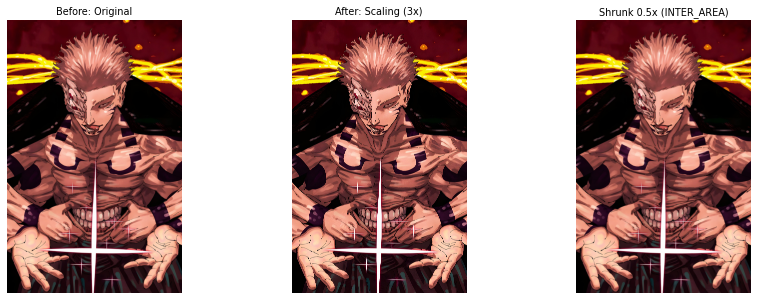

In [34]:
scale_x = scale_y = 3

# dsize=None -> OpenCV computes the new size from fx, fy
scaled = cv2.resize(image, None, fx=scale_x, fy=scale_y, interpolation=cv2.INTER_LINEAR)
shrunk = cv2.resize(image, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_AREA)   # best flag for shrinking

print("Original:", image.shape, "| Scaled x3:", scaled.shape, "| Shrunk x0.5:", shrunk.shape)

# Note: both plots look the same size because Matplotlib fits each into the same axes. Check the printed shapes.
show([image_rgb, bgr2rgb(scaled), bgr2rgb(shrunk)],
     ['Before: Original', f'After: Scaling ({scale_x}x)', 'Shrunk 0.5x (INTER_AREA)'], cols=3)

## A4. Shear
Slides each row sideways by an amount proportional to its y position: `x' = x + kx·y`. Rectangles become parallelograms. Parallel lines stay parallel, but angles change.

**🎯 When you'd use this:** simulating slanted handwriting or a viewing angle as data augmentation; un-slanting italic text before OCR.

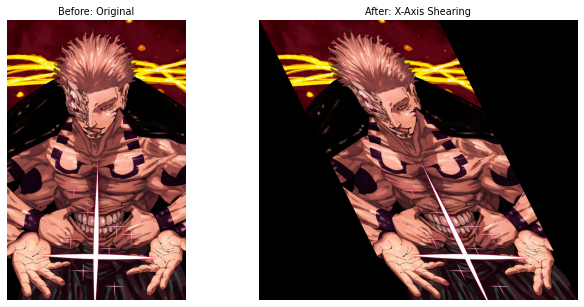

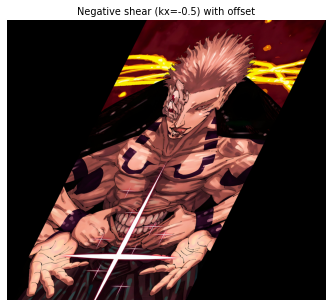

In [35]:
kx = 0.5                                   # shear factor (0.5 = bottom row moves 0.5*height pixels)

# X-shear matrix: x' = 1*x + kx*y + 0 ; y' = y
M = np.float32([[1, kx, 0],
                [0, 1,  0]])

# Widen the canvas so the sheared image is not clipped
new_width = int(width + abs(kx) * height)
sheared = cv2.warpAffine(image, M, (new_width, height))

show([image_rgb, bgr2rgb(sheared)], ['Before: Original', 'After: X-Axis Shearing'], cols=2, figsize=(10, 4.5))

# Negative kx: the image would slide off the LEFT edge, so add a positive x-offset to compensate
kx = -0.5
M_neg = np.float32([[1, kx, abs(kx) * height],
                    [0, 1,  0]])
sheared_neg = cv2.warpAffine(image, M_neg, (int(width + abs(kx) * height), height))
show([bgr2rgb(sheared_neg)], ['Negative shear (kx=-0.5) with offset'], cols=1, figsize=(6, 4.5))

## A5. Rigid transformation
Rotation + translation only. **Scale must stay 1.0**, otherwise it's a similarity transform. Shapes, sizes and angles are preserved, like moving a physical object. Here the translation is *added* to the rotation matrix's last column, which means "rotate about the centre, then move".

**🎯 When you'd use this:** image registration, e.g. aligning two scans of the same patient or two frames of a drone video, where the object only moved and must not be reshaped.

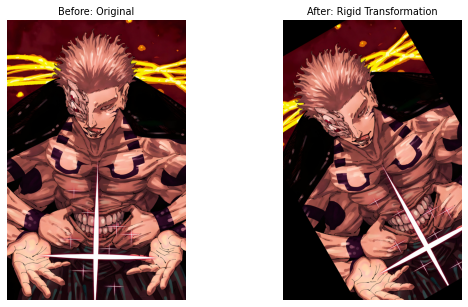

In [36]:
center = (width // 2, height // 2)
angle  = 30
scale  = 1.0                                  # MUST be 1.0 for a rigid transformation

M = cv2.getRotationMatrix2D(center, angle, scale)

# Add translation to the last column: M[0,2] is x-shift, M[1,2] is y-shift
M[0, 2] += 100
M[1, 2] += 50

rigid = cv2.warpAffine(image, M, (width, height))
show([image_rgb, bgr2rgb(rigid)], ['Before: Original', 'After: Rigid Transformation'], cols=2, figsize=(9, 4.5))

## A6. Perspective (projective / homography)
Simulates changing the camera viewpoint, so parallel lines can converge. It uses a **3×3 homography** with 8 free parameters, so you need **4 point pairs** (`getPerspectiveTransform`), then apply it with `warpPerspective`. No three of the four points may lie on a line.

**🎯 When you'd use this:** document scanner apps (flatten a photographed page); reading a license plate shot at an angle; bird's-eye view for lane detection; stitching panoramas.

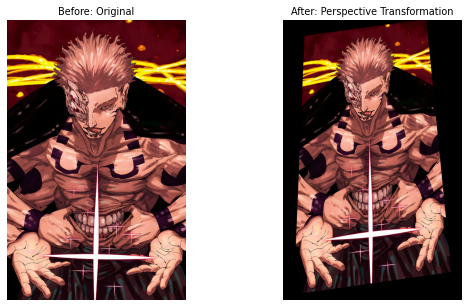

Homography (3x3):
 [[ 6.8190e-01 -4.6900e-02  3.1176e+02]
 [-9.4200e-02  6.9710e-01  2.4462e+02]
 [ 0.0000e+00 -1.0000e-04  1.0000e+00]]


In [37]:
# Source corners: the four corners of the image (x, y)
src_points = np.float32([[0, 0],
                         [width - 1, 0],
                         [width - 1, height - 1],
                         [0, height - 1]])

# Destination: where each corner should land. Defined as FRACTIONS of width/height so it works on any image size
# (the manual hard-codes pixels like width-150, which only suits one image size)
dst_points = np.float32([[0.12 * width, 0.06 * height],
                         [0.80 * width, 0.00 * height],
                         [0.94 * width, 0.90 * height],
                         [0.06 * width, 0.98 * height]])

M = cv2.getPerspectiveTransform(src_points, dst_points)          # 3x3 homography
perspective = cv2.warpPerspective(image, M, (width, height))

show([image_rgb, bgr2rgb(perspective)], ['Before: Original', 'After: Perspective Transformation'], cols=2, figsize=(9, 4.5))
print("Homography (3x3):\n", M.round(4))

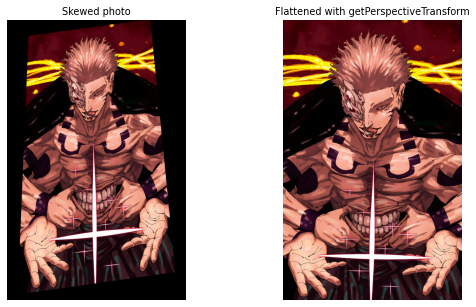

In [38]:
# ---------- Scenario: un-skew a photographed page (what a document-scanner app does) ----------
# Pretend `perspective` above is a photo taken at an angle. We know where its 4 corners are, so we map them back to a rectangle.
photo_corners = dst_points                       # corners of the content in the skewed photo (in a real app: found by a corner/contour detector)
flat_corners  = src_points                       # where they should be after flattening

M_fix = cv2.getPerspectiveTransform(photo_corners, flat_corners)     # note the swapped order: skewed -> flat
flattened = cv2.warpPerspective(perspective, M_fix, (width, height))

show([bgr2rgb(perspective), bgr2rgb(flattened)], ['Skewed photo', 'Flattened with getPerspectiveTransform'], cols=2, figsize=(9, 4.5))

## A7. Affine from 3 point pairs (extra)
Any affine transform (translation, rotation, scale, shear in one go) is fixed by **3** point pairs. Compare: perspective needs 4.

**🎯 When you'd use this:** aligning an image to a template using three known landmarks (e.g. both eyes and the mouth for a face).

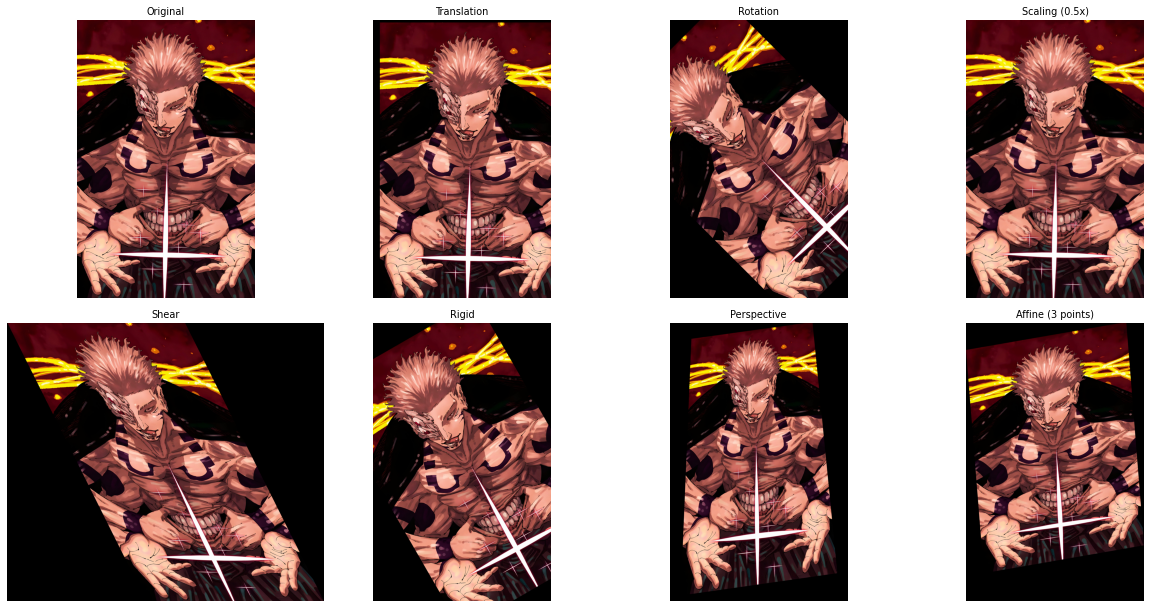

In [39]:
src3 = np.float32([[0, 0], [width - 1, 0], [0, height - 1]])
dst3 = np.float32([[0, 0.10 * height], [0.90 * width, 0], [0.10 * width, 0.90 * height]])

M = cv2.getAffineTransform(src3, dst3)               # 2x3
affine = cv2.warpAffine(image, M, (width, height))

# Side-by-side summary of everything in Part A
show([image_rgb, bgr2rgb(translated), bgr2rgb(rotated), bgr2rgb(shrunk), bgr2rgb(sheared), bgr2rgb(rigid), bgr2rgb(perspective), bgr2rgb(affine)],
     ['Original', 'Translation', 'Rotation', 'Scaling (0.5x)', 'Shear', 'Rigid', 'Perspective', 'Affine (3 points)'], cols=4)

---
# Part B: Lab 04, Feature Extraction

## 2. Introduction
Raw pixels are high-dimensional and noisy. **Feature extraction** turns an image into a compact vector that keeps what matters (shape, texture, colour) and drops the rest.

| | Local features | Global features |
|---|---|---|
| Computed from | specific regions: keypoints, corners, patches | the whole image |
| Examples | corners, SIFT/SURF | colour histogram, texture descriptors, image moments |
| Used for | matching, detection | classification, retrieval |

Techniques in this lab: **histogram-based** (HOG, LBP, colour, HED, HIG, texture), **filter-based** (convolution, Sobel, Canny), and CNN-learned features (not covered here). Real-world difficulty: lighting, scale, orientation and noise all change the features.

## B1. HOG: Histogram of Oriented Gradients
**Idea:** describe shape by the directions of local edges. Steps: grayscale → gradients (Sobel) → split into small cells (8×8) → histogram of gradient orientations per cell → normalise over blocks of 2×2 cells (reduces lighting effects) → concatenate into one feature vector.

**🎯 When you'd use this:** pedestrian/object detection with a classic pipeline (HOG + SVM); any task where *shape* matters more than colour, with a small dataset and no GPU.

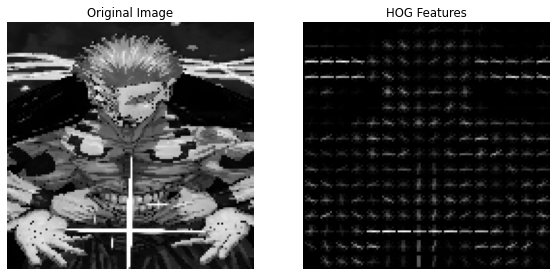

HOG feature vector length: 8100
First 10 values: [0.096 0.105 0.031 0.012 0.028 0.019 0.035 0.008 0.014 0.136]


In [40]:
from skimage.feature import hog
from skimage import exposure

# Read the image as grayscale (HOG works on intensity)
img_g = load_image(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)
img_g = cv2.resize(img_g, (128, 128))      # resized only to keep the vector small; the manual uses the full image

# pixels_per_cell: cell size | cells_per_block: block size for normalisation | visualize=True also returns a picture
features, hog_image = hog(img_g, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=True)

# Stretch intensity for display. (The manual uses in_range=(0, 10); the HOG image values are much smaller than 10,
# so using the real max gives a brighter, clearer picture.)
hog_image_rescaled = exposure.rescale_intensity(hog_image, in_range=(0, hog_image.max()))

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(img_g, cmap='gray'); ax[0].set_title('Original Image'); ax[0].axis('off')
ax[1].imshow(hog_image_rescaled, cmap='gray'); ax[1].set_title('HOG Features'); ax[1].axis('off')
plt.show()

# Vector length = (cells_y-1) * (cells_x-1) * (2*2 blocks) * 9 orientations = 15*15*36
print("HOG feature vector length:", features.shape[0])
print("First 10 values:", features[:10].round(3))

## B2. LBP: Local Binary Pattern
**Idea:** describe *texture* by comparing each pixel with its neighbours. Neighbour ≥ centre → 1, else 0. The 8 bits form a pattern; the **histogram of patterns** over the image is the feature vector. `method='uniform'` keeps only patterns with at most two 0↔1 transitions (plus one "other" bin), giving `n_points + 2` bins.

**🎯 When you'd use this:** texture classification (wood vs fabric vs metal), face recognition (LBPH), anywhere you need a feature that tolerates lighting changes (LBP only compares neighbours, so a uniform brightness shift doesn't change it).

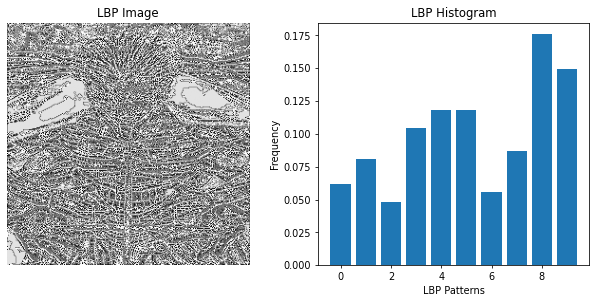

LBP Feature Vector:
[0.0616 0.0811 0.0485 0.1044 0.1182 0.1185 0.0554 0.0874 0.1759 0.1491]


In [41]:
from skimage import feature

image_l = cv2.resize(load_image(IMAGE_PATH, cv2.IMREAD_GRAYSCALE), (256, 256))

# Compute LBP features
radius   = 1            # radius of the circular neighbourhood
n_points = 8 * radius   # number of neighbours to compare against the centre
lbp_image = feature.local_binary_pattern(image_l, n_points, radius, method='uniform')

# Histogram of LBP codes: uniform LBP gives n_points + 2 distinct values (0 ... n_points+1)
hist, _ = np.histogram(lbp_image.ravel(), bins=np.arange(0, n_points + 3), range=(0, n_points + 2))

# Normalise so images of different sizes are comparable (1e-6 avoids division by zero)
hist = hist.astype("float")
hist /= (hist.sum() + 1e-6)

fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))
ax[0].imshow(lbp_image, cmap='gray'); ax[0].set_title('LBP Image'); ax[0].axis('off')
ax[1].bar(range(0, n_points + 2), hist); ax[1].set_title('LBP Histogram')
ax[1].set_xlabel('LBP Patterns'); ax[1].set_ylabel('Frequency')
plt.show()

print("LBP Feature Vector:")
print(hist.round(4))

## B3. Histogram of colour
**Idea:** count how many pixels fall into each colour bin. The manual only describes this one, so here is the code. A per-channel histogram has 256 bins per channel; a 3-D HSV histogram (8×8×8 = 512 bins) works better for comparing images.

**🎯 When you'd use this:** image retrieval ("find photos with similar colours"), sorting product photos by colour, quick scene classification (beach vs forest).

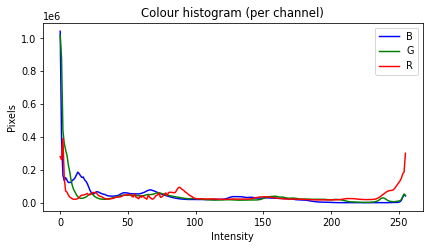

Feature length: 512
original vs brighter copy   : 0.541
original vs channel-swapped : 0.015


In [42]:
# ---- Per-channel histogram (OpenCV is BGR: channel 0=B, 1=G, 2=R) ----
plt.figure(figsize=(7, 3.5))
for i, c in enumerate(('b', 'g', 'r')):
    h = cv2.calcHist([image], [i], None, [256], [0, 256])     # images=[img], channels=[i], mask=None, bins=[256], range
    plt.plot(h, color=c, label=c.upper())
plt.title('Colour histogram (per channel)'); plt.xlabel('Intensity'); plt.ylabel('Pixels'); plt.legend(); plt.show()

# ---- 3-D HSV histogram as a feature vector (8 bins per channel). OpenCV hue range is 0-179 ----
def color_feature(bgr, bins=8):
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    h = cv2.calcHist([hsv], [0, 1, 2], None, [bins] * 3, [0, 180, 0, 256, 0, 256]).flatten()
    return (h / h.sum()).astype(np.float32)

f_orig   = color_feature(image)
f_bright = color_feature(cv2.convertScaleAbs(image, alpha=1.0, beta=15))   # slightly brighter copy
f_other  = color_feature(image[..., ::-1])                                  # channels swapped = very different colours
print("Feature length:", f_orig.shape[0])

# Compare histograms: HISTCMP_CORREL gives 1.0 = identical, lower = more different
print("original vs brighter copy   :", round(cv2.compareHist(f_orig, f_bright, cv2.HISTCMP_CORREL), 3))
print("original vs channel-swapped :", round(cv2.compareHist(f_orig, f_other,  cv2.HISTCMP_CORREL), 3))

## B4. HED: Histogram of Edge Directions
**Idea:** find edges, measure the direction of each edge pixel, and count how many fall in each of 8 direction bins (45° each). Tells you whether an image is dominated by horizontal, vertical or diagonal structure.

**🎯 When you'd use this:** telling man-made scenes (strong vertical/horizontal edges) from natural ones; orientation of text lines or textures; a quick shape descriptor for sketches or logos.

**Bugs in the manual's code (checked):**
1. `np.arctan2` returns angles in **-180° to +180°**, but the histogram range is `(0, 360)`, so **every pixel with a negative angle is silently dropped**. That is roughly half of the pixels that have a real gradient (on the demo image it is 16% of all pixels, because flat areas have angle 0 and stay in the first bin, which also inflates that bin).
2. The Canny edge map is computed, but the histogram is built from **every pixel**, not just the edge pixels. Flat regions add noise (their direction is meaningless).

In [43]:
# ---------------- Manual version ----------------
image_s = cv2.GaussianBlur(load_image(IMAGE_PATH, cv2.IMREAD_GRAYSCALE), (5, 5), 0)    # optional smoothing to reduce noise

edges = cv2.Canny(image_s, threshold1=30, threshold2=70)       # edge map

# Gradients: dtype CV_64F (float) so negative values are kept; (1,0)=d/dx, (0,1)=d/dy
gradient_x = cv2.Sobel(image_s, cv2.CV_64F, 1, 0, ksize=3)
gradient_y = cv2.Sobel(image_s, cv2.CV_64F, 0, 1, ksize=3)
gradient_orientation = np.arctan2(gradient_y, gradient_x) * 180 / np.pi    # -180 ... +180

hist_manual, bin_edges = np.histogram(gradient_orientation, bins=8, range=(0, 360))
print("Pixels in image            :", gradient_orientation.size)
print("Pixels counted (manual)    :", hist_manual.sum(), " <- negative angles were dropped")

Pixels in image            : 10592046
Pixels counted (manual)    : 6659091  <- negative angles were dropped


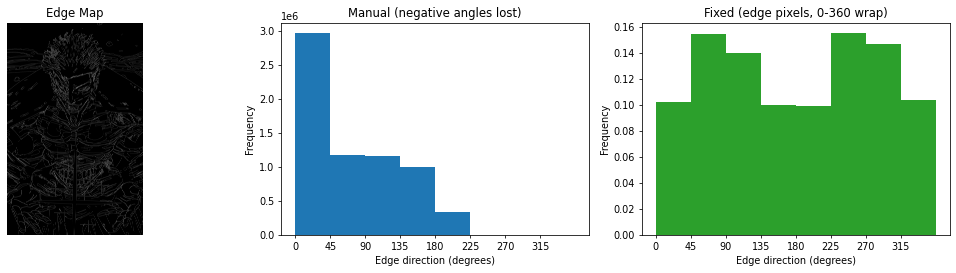

HED feature vector (8 bins, normalised): [0.102 0.154 0.14  0.1   0.099 0.155 0.146 0.104]


In [44]:
# ---------------- Fixed version ----------------
# 1) wrap angles into 0-360 with modulo so nothing is dropped
orientation = np.degrees(np.arctan2(gradient_y, gradient_x)) % 360
# 2) only count pixels that are actually on an edge
edge_mask = edges > 0

hist_fixed, bin_edges = np.histogram(orientation[edge_mask], bins=8, range=(0, 360))
hist_fixed_norm = hist_fixed / hist_fixed.sum()               # normalise: image size no longer matters

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
ax[0].imshow(edges, cmap='gray'); ax[0].set_title('Edge Map'); ax[0].axis('off')
ax[1].bar(bin_edges[:-1], hist_manual, width=45, align='edge'); ax[1].set_title('Manual (negative angles lost)')
ax[2].bar(bin_edges[:-1], hist_fixed_norm, width=45, align='edge', color='tab:green'); ax[2].set_title('Fixed (edge pixels, 0-360 wrap)')
for a in ax[1:]:
    a.set_xlabel('Edge direction (degrees)'); a.set_ylabel('Frequency'); a.set_xticks(range(0, 360, 45))
plt.tight_layout(); plt.show()

print("HED feature vector (8 bins, normalised):", hist_fixed_norm.round(3))

## B5. HIG: Histogram of Intensity Gradients
**Idea:** the same as HED but for the whole image's gradients (no edge map). Magnitude `G = √(dx²+dy²)`, orientation `θ = atan2(dy, dx)`. This is essentially one global cell of HOG.

**🎯 When you'd use this:** a cheap global descriptor for classification when you don't need HOG's spatial layout; comparing the "texture direction" of two images.

**Bugs in the manual's code (checked):** (1) same range issue: signed angles from `arctan2` with `range=(0, 180)` drop every negative angle; (2) `magnitude` is computed but never used, so a strong edge counts the same as faint noise. Standard practice (as in HOG) is *unsigned* orientation (0-180°) **weighted by magnitude**.

Manual: pixels counted 6517877 of 10592046


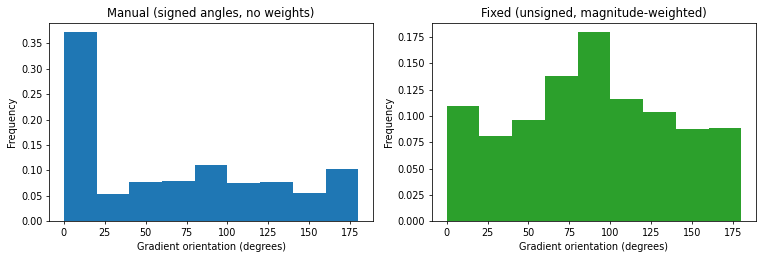

HIG feature vector: [0.11  0.081 0.096 0.138 0.179 0.116 0.104 0.087 0.088]


In [45]:
# ---------------- Manual version ----------------
img_h = load_image(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)
dx = cv2.Sobel(img_h, cv2.CV_64F, 1, 0, ksize=3)                    # horizontal gradient
dy = cv2.Sobel(img_h, cv2.CV_64F, 0, 1, ksize=3)                    # vertical gradient

magnitude   = np.sqrt(dx**2 + dy**2)                                # edge strength
orientation = np.arctan2(dy, dx) * (180 / np.pi)                    # radians -> degrees (-180...180)

histogram, bins = np.histogram(orientation, bins=9, range=(0, 180))
histogram_manual = histogram / histogram.sum()                      # normalise
print("Manual: pixels counted", histogram.sum(), "of", orientation.size)

# ---------------- Fixed version: unsigned angle + magnitude weights ----------------
orientation_u = orientation % 180
histogram_fixed, bins = np.histogram(orientation_u, bins=9, range=(0, 180), weights=magnitude)
histogram_fixed = histogram_fixed / histogram_fixed.sum()

fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
ax[0].bar(bins[:-1], histogram_manual, width=20, align='edge'); ax[0].set_title('Manual (signed angles, no weights)')
ax[1].bar(bins[:-1], histogram_fixed, width=20, align='edge', color='tab:green'); ax[1].set_title('Fixed (unsigned, magnitude-weighted)')
for a in ax: a.set_xlabel('Gradient orientation (degrees)'); a.set_ylabel('Frequency')
plt.tight_layout(); plt.show()
print("HIG feature vector:", histogram_fixed.round(3))

## B6. Texture energy and contrast
- **Energy** = sum of squared pixel values in a local window. Large where the region is bright/busy.
- **Contrast** = standard deviation of pixel values in the window. Large where intensity varies a lot; ≈0 on flat areas.
Build a histogram of each over the image → feature vectors.

**🎯 When you'd use this:** separating smooth surfaces from rough ones (polished metal vs sandpaper), defect detection (a scratch raises local contrast), segmenting a scene into smooth/textured regions.

**Bugs in the manual's code (checked):**
1. `image ** 2` on a `uint8` image **overflows** (values wrap at 255: the max squared value I measured was 249 when it should be up to 64,516). Convert to `float32` first.
2. "Contrast" is computed as `filter2D(image, ones)`, which is a local **sum** (the same kind of thing as brightness), **not a standard deviation** as the text says. Compute `sqrt(E[x²] − E[x]²)` instead.

In [46]:
# ---------------- Manual version ----------------
image_t = load_image(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)
neighborhood_size = 3                                                   # 3x3 window

energy_manual   = cv2.filter2D(image_t ** 2, -1, np.ones((neighborhood_size, neighborhood_size)))    # uint8 overflow!
contrast_manual = cv2.filter2D(image_t,      -1, np.ones((neighborhood_size, neighborhood_size)))    # just a local sum
print("image**2 dtype:", (image_t ** 2).dtype, "| max after squaring:", (image_t ** 2).max(), "(true max would be", int(image_t.max()) ** 2, ")")

image**2 dtype: uint8 | max after squaring: 249 (true max would be 65025 )


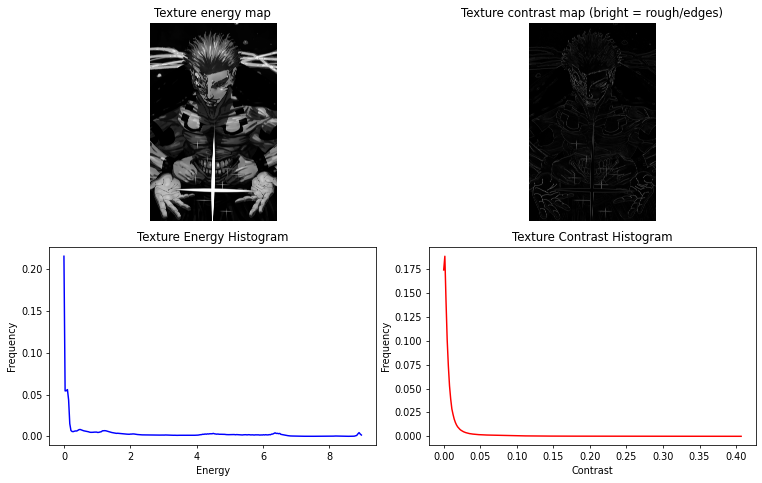

In [47]:
# ---------------- Fixed version ----------------
img_f = image_t.astype(np.float32) / 255.0          # float so squaring cannot overflow (scaled to 0-1)
k = neighborhood_size

mean_local = cv2.boxFilter(img_f,      -1, (k, k))                      # E[x]   (normalised box = local mean)
sq_local   = cv2.boxFilter(img_f ** 2, -1, (k, k))                      # E[x^2]

energy   = sq_local * k * k                                            # sum of squares in the window
contrast = np.sqrt(np.maximum(sq_local - mean_local ** 2, 0))          # std-dev = sqrt(E[x^2] - E[x]^2)

# Histograms of energy / contrast (range up to the max value, as in the manual) -> feature vectors
energy_hist,   energy_bins   = np.histogram(energy,   bins=256, range=(0, energy.max()))
contrast_hist, contrast_bins = np.histogram(contrast, bins=256, range=(0, contrast.max()))
energy_hist   = energy_hist / energy_hist.sum()                         # normalise (optional)
contrast_hist = contrast_hist / contrast_hist.sum()

fig, ax = plt.subplots(2, 2, figsize=(11, 7))
ax[0, 0].imshow(energy, cmap='gray');   ax[0, 0].set_title('Texture energy map');   ax[0, 0].axis('off')
ax[0, 1].imshow(contrast, cmap='gray'); ax[0, 1].set_title('Texture contrast map (bright = rough/edges)'); ax[0, 1].axis('off')
ax[1, 0].plot(energy_bins[:-1], energy_hist, color='b');     ax[1, 0].set_title('Texture Energy Histogram');   ax[1, 0].set_xlabel('Energy');   ax[1, 0].set_ylabel('Frequency')
ax[1, 1].plot(contrast_bins[:-1], contrast_hist, color='r'); ax[1, 1].set_title('Texture Contrast Histogram'); ax[1, 1].set_xlabel('Contrast'); ax[1, 1].set_ylabel('Frequency')
plt.tight_layout(); plt.show()

## B7. Task: texture analysis for material classification
*Manual task: classify wood, metal and fabric; describe two texture techniques, how they work, which textures suit them, and their advantages/limitations.*

I use **LBP** (local micro-pattern) and **texture energy/contrast** (local intensity statistics). The cell below builds **synthetic** wood, metal and fabric textures (so it runs without a dataset), extracts the features and trains an SVM. With real photos you'd replace the generator with `cv2.imread` over a folder of labelled images.

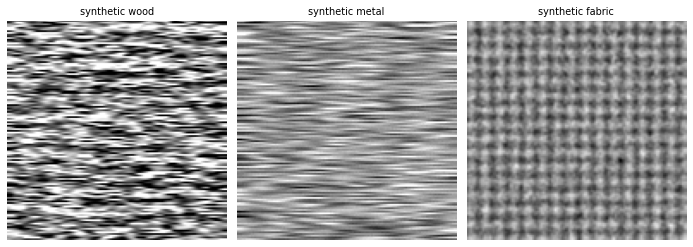

              precision    recall  f1-score   support

      fabric       1.00      1.00      1.00        18
       metal       1.00      1.00      1.00        18
        wood       1.00      1.00      1.00        18

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54

Confusion matrix (rows=true, cols=pred; order wood, metal, fabric):
[[18  0  0]
 [ 0 18  0]
 [ 0  0 18]]


In [48]:
from skimage.feature import local_binary_pattern
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

N = 128
def _noise(rng, sigma=None, ksize=(0, 0)):
    return cv2.GaussianBlur(rng.normal(0, 1, (N, N)).astype(np.float32), ksize, sigma or 0)

def synth_wood(rng):
    # curved growth rings + fine grain along one direction
    yy, xx = np.mgrid[0:N, 0:N].astype(np.float32)
    warp = _noise(rng, 12) * rng.uniform(40, 120)
    rings = 0.5 + 0.22 * np.sin(2 * np.pi * (yy + warp) / rng.uniform(8, 16))
    grain = _noise(rng, ksize=(15, 1)) * rng.uniform(0.5, 1.2)
    return rings + grain + rng.uniform(-0.1, 0.15)

def synth_metal(rng):
    # smooth sheen with faint brushed streaks
    xx = np.mgrid[0:N, 0:N][1].astype(np.float32)
    sheen = 0.55 + 0.12 * (xx / N - 0.5) * rng.uniform(-1, 1)
    streaks = _noise(rng, ksize=(31, 1)) * rng.uniform(0.3, 0.8)
    return sheen + streaks + rng.normal(0, 0.012, (N, N)) + rng.uniform(-0.1, 0.15)

def synth_fabric(rng):
    # regular woven grid + thread noise
    yy, xx = np.mgrid[0:N, 0:N].astype(np.float32)
    p = rng.uniform(5, 9)
    weave = 0.5 + 0.12 * (np.sin(2 * np.pi * xx / p) + np.sin(2 * np.pi * yy / p))
    return weave + _noise(rng, 0.8) * rng.uniform(0.15, 0.5) + rng.uniform(-0.1, 0.15)

def texture_features(g01):
    g8 = np.clip(g01 * 255, 0, 255).astype(np.uint8)
    # --- Technique 1: LBP (uniform, P=8, R=1) -> 10-bin normalised histogram
    lbp = local_binary_pattern(g8, 8, 1, method='uniform')
    h, _ = np.histogram(lbp.ravel(), bins=np.arange(0, 11))
    h = h / h.sum()
    # --- Technique 2: local energy / contrast statistics in a 5x5 window
    k = 5
    g = np.clip(g01, 0, 1).astype(np.float32)
    mean, sq = cv2.boxFilter(g, -1, (k, k)), cv2.boxFilter(g * g, -1, (k, k))
    contrast = np.sqrt(np.maximum(sq - mean ** 2, 0)); energy = sq * k * k
    return np.concatenate([h, [energy.mean(), energy.std(), contrast.mean(), contrast.std()]])

rng = np.random.default_rng(42)
makers = {'wood': synth_wood, 'metal': synth_metal, 'fabric': synth_fabric}
X, y, samples = [], [], {}
for label, fn in makers.items():
    for i in range(60):
        t = fn(rng)
        X.append(texture_features(t)); y.append(label)
        if i == 0: samples[label] = np.clip(t * 255, 0, 255).astype(np.uint8)
X, y = np.array(X), np.array(y)
show(list(samples.values()), [f'synthetic {k}' for k in samples], cols=3, figsize=(10, 3.6))

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, stratify=y, random_state=0)
clf = make_pipeline(StandardScaler(), SVC(kernel='rbf', C=10))      # scaling matters: LBP bins are ~0-1, energy is much larger
clf.fit(X_tr, y_tr)
pred = clf.predict(X_te)
print(classification_report(y_te, pred))
print("Confusion matrix (rows=true, cols=pred; order wood, metal, fabric):")
print(confusion_matrix(y_te, pred, labels=['wood', 'metal', 'fabric']))

**Description (for the task write-up)**

| Technique | How it works | Suits |
|---|---|---|
| **LBP** | Compares each pixel to its circular neighbours, encodes the result as a binary pattern, and histograms the patterns | **Fabric** (repeating weave gives a few dominant patterns), **wood** (grain/rings give directional patterns) |
| **Texture energy & contrast** | Local sum of squares and local standard deviation in a window, summarised by mean/std or histogram | **Metal** (smooth: low contrast) vs **wood/fabric** (rough: higher contrast) |

**Advantages:** both are cheap, need no GPU, produce short vectors, and work with small datasets. LBP is robust to uniform lighting changes.
**Limitations:** LBP at radius 1 sees only fine detail, so large-scale patterns are missed (use several radii). It is not rotation invariant (unless you use the rotation-invariant variants). Energy/contrast change with exposure and need normalisation. Both fail when different materials look alike (wood-grain laminate vs real wood). The 100% accuracy above only shows the pipeline works: the synthetic textures are easy to separate. On real photos expect noticeably lower accuracy (lighting, scale and rotation all vary), and a CNN would usually beat these hand-made features if you have enough data.

---
## 4. Filtering & convolution
A **filter (kernel)** is a small matrix. **Convolution** slides it over the image, multiplies element-wise with the pixels under it, sums the result, and writes it to the output pixel. Different kernels give blur, sharpen, edges, emboss.

## B8. Filters from the manual

In [49]:
# A colour image works with filter2D (applied to each channel); grayscale is used for the edge examples
img_c = image.copy()
img_k = gray.copy()

# ---------- Box blur: each pixel becomes the AVERAGE of its 3x3 neighbourhood ----------
kernel = np.ones((3, 3), dtype=np.float32) / 9           # all weights equal, sum = 1 so brightness is preserved
blurred_image = cv2.filter2D(img_c, -1, kernel)           # ddepth=-1 -> output has the same depth as the input
print("Same as cv2.blur(3x3)?  max diff =", np.abs(blurred_image.astype(int) - cv2.blur(img_c, (3, 3)).astype(int)).max())

Same as cv2.blur(3x3)?  max diff = 0


**🎯 Box blur:** quick noise reduction/smoothing, e.g. pre-smoothing before downsampling a camera frame.

**Gaussian blur, manual version.** `cv2.getGaussianKernel(5, sigma)` returns a **1-D column vector of shape (5, 1)**, not a 5×5 kernel. Passing it to `filter2D` therefore blurs **only vertically**. Build the 2-D kernel with an outer product (or just use `cv2.GaussianBlur`).

getGaussianKernel shape: (5, 1)
fixed vs cv2.GaussianBlur max diff: 1


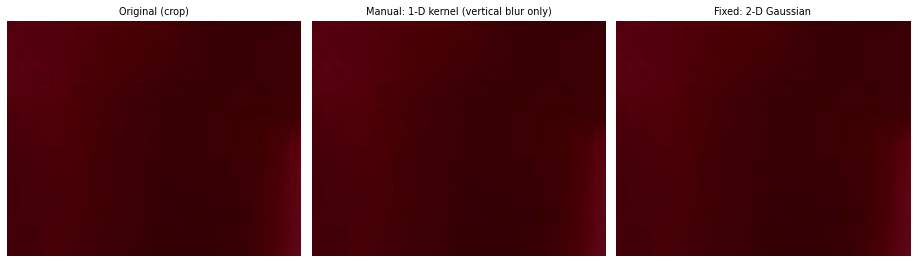

In [50]:
kernel_size = (5, 5)
sigma = 1.0
k1d = cv2.getGaussianKernel(kernel_size[0], sigma)            # shape (5, 1): a 1-D kernel
print("getGaussianKernel shape:", k1d.shape)

gaussian_manual = cv2.filter2D(img_c, -1, k1d)                # manual version: vertical-only blur
k2d = k1d @ k1d.T                                             # outer product -> true 5x5 Gaussian kernel (sums to 1)
gaussian_fixed  = cv2.filter2D(img_c, -1, k2d)                # fixed
gaussian_cv     = cv2.GaussianBlur(img_c, kernel_size, sigma) # built-in does the same in one call

print("fixed vs cv2.GaussianBlur max diff:", np.abs(gaussian_fixed.astype(int) - gaussian_cv.astype(int)).max())
show([bgr2rgb(img_c[100:260, 40:240]), bgr2rgb(gaussian_manual[100:260, 40:240]), bgr2rgb(gaussian_fixed[100:260, 40:240])],
     ['Original (crop)', 'Manual: 1-D kernel (vertical blur only)', 'Fixed: 2-D Gaussian'], cols=3)

**🎯 Gaussian blur:** the standard pre-step before edge detection, thresholding or Canny, because it removes noise without the blockiness of a box filter. In the middle plot above, fine horizontal detail (window edges) is still sharp, which shows the blur only ran in one direction.

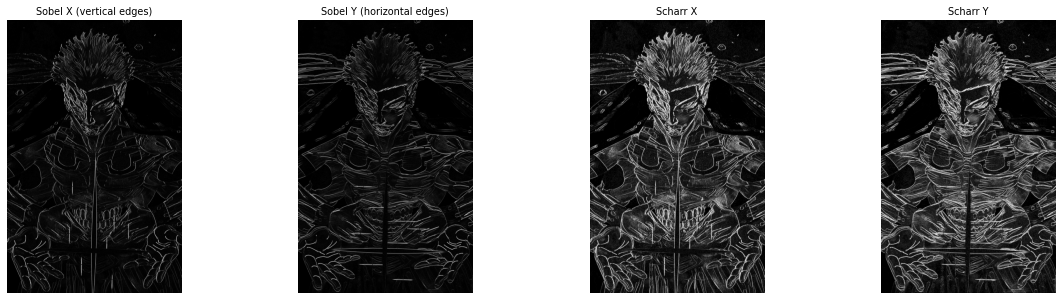

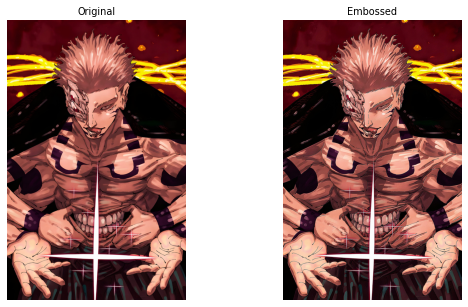

In [51]:
# ---------- Sobel & Scharr: gradient (edge) kernels ----------
# cv2.CV_64F keeps negative values (dark->bright vs bright->dark); uint8 output would clip them to 0.
# args: (src, ddepth, dx, dy): dx=1,dy=0 detects VERTICAL edges (change along x); dx=0,dy=1 detects HORIZONTAL edges
sobel_x  = cv2.Sobel(img_k, cv2.CV_64F, 1, 0, ksize=3)
sobel_y  = cv2.Sobel(img_k, cv2.CV_64F, 0, 1, ksize=3)
scharr_x = cv2.Scharr(img_k, cv2.CV_64F, 1, 0)             # 3x3 only; more accurate rotation response than Sobel 3x3
scharr_y = cv2.Scharr(img_k, cv2.CV_64F, 0, 1)

# convertScaleAbs takes |value| and converts to uint8 for display
show([cv2.convertScaleAbs(sobel_x), cv2.convertScaleAbs(sobel_y), cv2.convertScaleAbs(scharr_x), cv2.convertScaleAbs(scharr_y)],
     ['Sobel X (vertical edges)', 'Sobel Y (horizontal edges)', 'Scharr X', 'Scharr Y'], cols=4)

# ---------- Embossing: gives a 3-D relief look ----------
kernel = np.array([[-2, -1, 0],
                   [-1,  1, 1],
                   [ 0,  1, 2]], dtype=np.float32)
embossed_image = cv2.filter2D(img_c, -1, kernel)
show([bgr2rgb(img_c), bgr2rgb(embossed_image)], ['Original', 'Embossed'], cols=2, figsize=(9, 4.5))

**🎯 Sobel/Scharr:** finding edges and gradient directions (the input to HOG, HED, HIG and Canny). Scharr is preferred when you need accurate gradient angles with a 3×3 kernel. **🎯 Emboss:** artistic effects, highlighting surface relief in scans.

---
## B9. Convolution types
Two things set the output size: **padding** (what happens at the border) and **stride** (how far the kernel jumps). For input `H`, kernel `k`, padding `p`, stride `s`:  `out = floor((H + 2p − k) / s) + 1`.

| Type | Padding | Output size (3×3 kernel) |
|---|---|---|
| **Valid** | none, the kernel must fully overlap | `H − 2` (shrinks) |
| **Same** | zero padding (`p = 1`) | `H` (same as input) |
| **Valid + stride 2** | none, skips every other position | about `(H − 3)/2 + 1` |

**What `cv2.filter2D` actually does** (this is where the manual's snippets go wrong):
- It always returns an image the **same size as the input**. There is no "valid" mode.
- It has **no `strides` argument**, so the manual's `filter2D(..., strides=(2, 2))` raises an error. I ran it to confirm.
- Default border is `BORDER_REFLECT_101` (mirrors pixels). `BORDER_CONSTANT` pads with **zeros**, so *that* is the real "same / zero padding" option. The manual puts `BORDER_CONSTANT` under "valid" and `BORDER_REFLECT` under "zero padding", which is backwards.
- It computes **correlation** (kernel not flipped). True convolution flips the kernel 180°. For symmetric kernels (blur) they are identical; for edge kernels the sign flips.

standard : (4077, 2598) (input (4077, 2598) )
true convolution = -correlation for this kernel? True
same/zero: (4077, 2598)
valid    : (4075, 2596) = (H-2, W-2) = (4075, 2596)
valid s=2: (2038, 1298) | formula floor((H-3)/2)+1 = (2038, 1298)


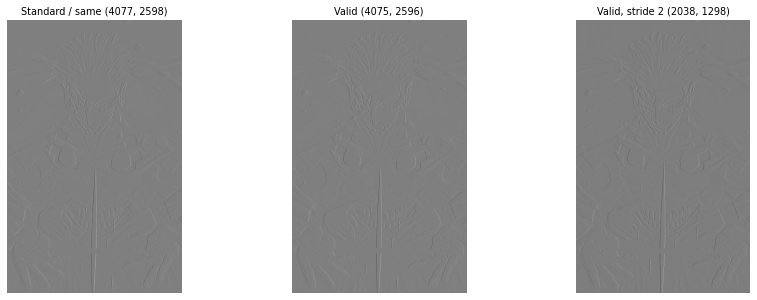

In [52]:
# kernel from the manual (a Sobel-like vertical-edge detector)
kernel = np.array([[1, 0, -1],
                   [2, 0, -2],
                   [1, 0, -1]], dtype=np.float32)
img32 = img_k.astype(np.float32)
H, W = img32.shape

# ---------- Standard convolution (filter2D default: output = input size, mirrored borders) ----------
standard = cv2.filter2D(img32, -1, kernel)
print("standard :", standard.shape, "(input", img32.shape, ")")

# ---------- Correlation vs true convolution ----------
true_conv = cv2.filter2D(img32, -1, cv2.flip(kernel, -1))       # flip the kernel on both axes = real convolution
print("true convolution = -correlation for this kernel?", np.allclose(true_conv[2:-2, 2:-2], -standard[2:-2, 2:-2]))

# ---------- Same convolution (zero padding): BORDER_CONSTANT pads with 0 ----------
same_zero = cv2.filter2D(img32, -1, kernel, borderType=cv2.BORDER_CONSTANT)
print("same/zero:", same_zero.shape)

# ---------- Valid convolution (no padding): compute, then drop the border the kernel couldn't fully cover ----------
p = kernel.shape[0] // 2
valid = same_zero[p:-p, p:-p]
print("valid    :", valid.shape, "= (H-2, W-2) =", (H - 2, W - 2))

# ---------- Valid convolution with stride 2: keep every 2nd output (filter2D can't stride, so slice) ----------
valid_s2 = valid[::2, ::2]
print("valid s=2:", valid_s2.shape, "| formula floor((H-3)/2)+1 =", ((H - 3) // 2 + 1, (W - 3) // 2 + 1))

show([norm8(standard), norm8(valid), norm8(valid_s2)],
     [f'Standard / same {standard.shape}', f'Valid {valid.shape}', f'Valid, stride 2 {valid_s2.shape}'], cols=3)

**🎯 When you'd use each:** *Same* when you need the output aligned with the input (edge map overlaid on the photo, U-Net style segmentation). *Valid* when border pixels would be unreliable. *Stride 2* to **downsample** while filtering, which is how CNN layers shrink feature maps (cheaper, bigger receptive field). The next cell implements all three from scratch so you can see the formula in action; it matches OpenCV.

In [53]:
from numpy.lib.stride_tricks import sliding_window_view

def conv2d(img, kernel, stride=1, padding=0, flip=False):
    # Minimal 2-D convolution. padding = zeros added on every side; stride = step between kernel positions.
    # flip=False -> correlation (what filter2D / CNN layers do); flip=True -> true mathematical convolution.
    k = np.flip(kernel) if flip else kernel
    if padding: img = np.pad(img, padding)                              # zero padding
    windows = sliding_window_view(img, k.shape)[::stride, ::stride]     # all kernel-sized patches, strided
    return (windows * k).sum(axis=(-1, -2))                             # element-wise multiply, then sum = dot product per patch

a = conv2d(img32, kernel, stride=1, padding=0)       # valid
b = conv2d(img32, kernel, stride=1, padding=1)       # same
c = conv2d(img32, kernel, stride=2, padding=0)       # valid, stride 2
print("valid  ", a.shape, " matches filter2D-based:", np.allclose(a, valid, atol=1e-3))
print("same   ", b.shape, " matches filter2D zero-pad:", np.allclose(b, same_zero, atol=1e-3))
print("stride2", c.shape, " matches sliced valid:", np.allclose(c, valid_s2, atol=1e-3))

valid   (4075, 2596)  matches filter2D-based: True
same    (4077, 2598)  matches filter2D zero-pad: True
stride2 (2038, 1298)  matches sliced valid: True


---
## 5. Edge detection
An **edge** is a boundary where intensity, colour or texture changes quickly. Edge maps shrink the data while keeping the structure, which is why they are a common pre-step for detection and segmentation.

| Technique | Idea | Use it when |
|---|---|---|
| **Sobel / Prewitt / Scharr** | first derivative: edges where gradient magnitude is high | quick edge strength + direction; simple, but thick edges and noise-sensitive |
| **Laplacian of Gaussian (LoG) / Marr-Hildreth** | blur, then second derivative; edges = zero-crossings | you want edges independent of direction, at a chosen blur scale |
| **Canny** | smooth → gradient → non-max suppression → hysteresis thresholds | the default choice: thin, connected, low-noise edges |
| **Sobel-Feldman** | the Sobel kernel's original name; Scharr is its optimised variant | accurate angles with 3×3 |
| **CNN-based (e.g. HED net)** | learn edges from labelled data | natural images where classical edges are too noisy |

## B10. Gradient-based edges (manual code)
The manual ends with `cv2.imshow` / `waitKey`, which **freezes Jupyter**, so the display part uses Matplotlib here.

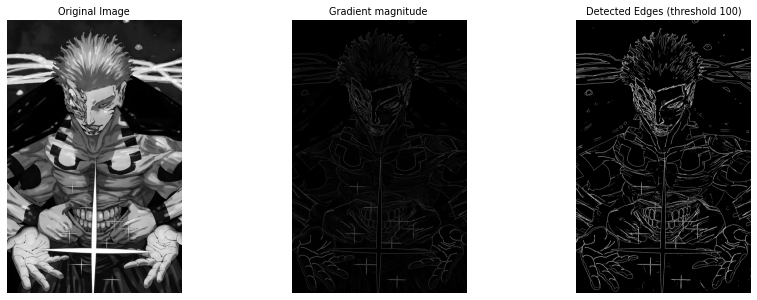

In [54]:
image_e = img_k                                             # grayscale

# Apply the Sobel operator to calculate gradients
gradient_x = cv2.Sobel(image_e, cv2.CV_64F, 1, 0, ksize=3)  # gradient in the x-direction
gradient_y = cv2.Sobel(image_e, cv2.CV_64F, 0, 1, ksize=3)  # gradient in the y-direction

# Gradient magnitude (edge strength) and direction (edge angle, radians)
gradient_magnitude = np.sqrt(gradient_x ** 2 + gradient_y ** 2)
gradient_direction = np.arctan2(gradient_y, gradient_x)

# Threshold the magnitude to get a binary edge map
threshold = 100
edges = (gradient_magnitude > threshold).astype(np.uint8) * 255

# In a plain script you would use cv2.imshow + cv2.waitKey(0) + cv2.destroyAllWindows(); in Jupyter use Matplotlib
show([image_e, norm8(gradient_magnitude), edges], ['Original Image', 'Gradient magnitude', f'Detected Edges (threshold {threshold})'], cols=3)

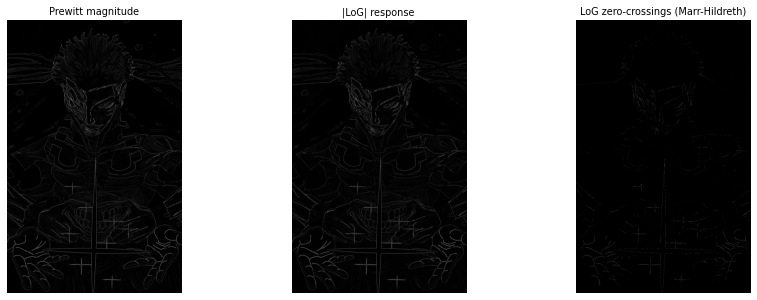

In [55]:
# ---------- Other techniques from section 5.1 ----------
# Prewitt: like Sobel but with equal weights (no centre emphasis); OpenCV has no built-in so use filter2D
prewitt_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]], dtype=np.float32)
prewitt_y = prewitt_x.T
px = cv2.filter2D(image_e.astype(np.float32), -1, prewitt_x)
py = cv2.filter2D(image_e.astype(np.float32), -1, prewitt_y)
prewitt_mag = np.hypot(px, py)

# Laplacian of Gaussian (Marr-Hildreth): blur first (noise makes the Laplacian explode), then 2nd derivative
log = cv2.Laplacian(cv2.GaussianBlur(image_e, (5, 5), 1.4), cv2.CV_64F, ksize=3)
# Edges are the ZERO-CROSSINGS of the LoG response: pixels where the sign flips between neighbours
sign = np.sign(log)
zero_cross = ((sign[:, :-1] * sign[:, 1:] < 0)[:-1, :] | (sign[:-1, :] * sign[1:, :] < 0)[:, :-1])
zero_cross = (zero_cross & (np.abs(log[:-1, :-1]) > 0.15 * np.abs(log).max()))      # ignore weak crossings (noise)

show([norm8(prewitt_mag), norm8(np.abs(log)), zero_cross.astype(np.uint8) * 255],
     ['Prewitt magnitude', '|LoG| response', 'LoG zero-crossings (Marr-Hildreth)'], cols=3)

## B11. The Canny edge detector
Four stages (John Canny, 1986):
1. **Gaussian smoothing:** reduces noise. Larger σ = smoother but loses fine detail.
2. **Gradient calculation:** Sobel in x and y → magnitude and direction per pixel.
3. **Non-maximum suppression:** keep a pixel only if it is the strongest among its neighbours *along the gradient direction* → edges become 1 pixel thin.
4. **Hysteresis thresholding:** `T_high`: definitely an edge. Below `T_low`: rejected. In between: kept **only if connected to a strong edge** → continuous lines, little speckle.

`cv2.Canny(image, threshold1, threshold2)`: `threshold1 = T_low`, `threshold2 = T_high` (a ratio of 1:2 or 1:3 is typical). Optional: `apertureSize` (Sobel size, 3/5/7), `L2gradient=True` (accurate √(dx²+dy²) instead of |dx|+|dy|).

**🎯 When you'd use this:** lane detection, finding object outlines before contour detection, document edge detection (scanner apps), pre-processing for Hough line/circle detection.

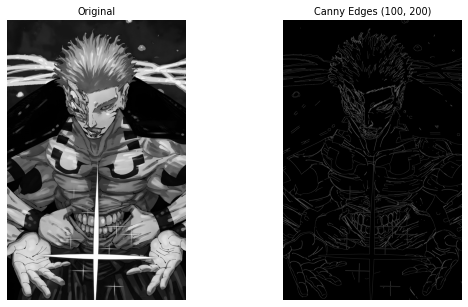

In [56]:
# ---------- Manual version ----------
canny_manual = cv2.Canny(gray, threshold1=100, threshold2=200)    # adjust thresholds as needed
show([gray, canny_manual], ['Original', 'Canny Edges (100, 200)'], cols=2, figsize=(9, 4.5))

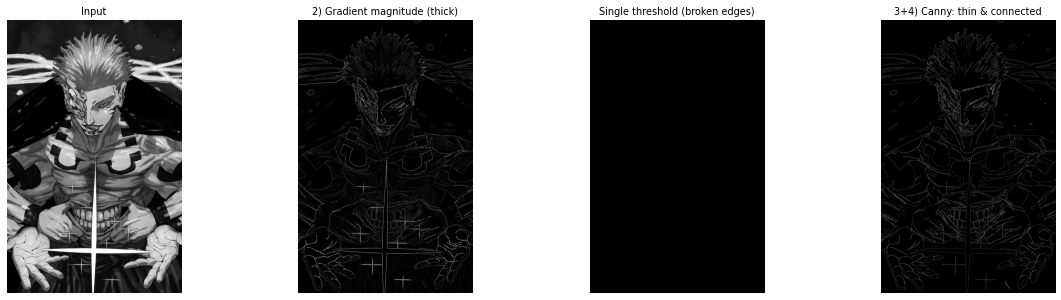

In [57]:
# ---------- Seeing the stages ----------
smooth = cv2.GaussianBlur(gray, (5, 5), 1.4)                            # stage 1
gx = cv2.Sobel(smooth, cv2.CV_64F, 1, 0); gy = cv2.Sobel(smooth, cv2.CV_64F, 0, 1)
mag = np.hypot(gx, gy)                                                  # stage 2 (thick edges)

T_low, T_high = 50, 150
strong_only = (mag > T_high * 4).astype(np.uint8) * 255                 # naive "strong" threshold on the magnitude (Sobel scale differs from Canny's, hence x4 for display)
canny = cv2.Canny(smooth, T_low, T_high)                                # stages 3+4 (thin + hysteresis)

show([gray, norm8(mag), strong_only, canny],
     ['Input', '2) Gradient magnitude (thick)', 'Single threshold (broken edges)', '3+4) Canny: thin & connected'], cols=4)

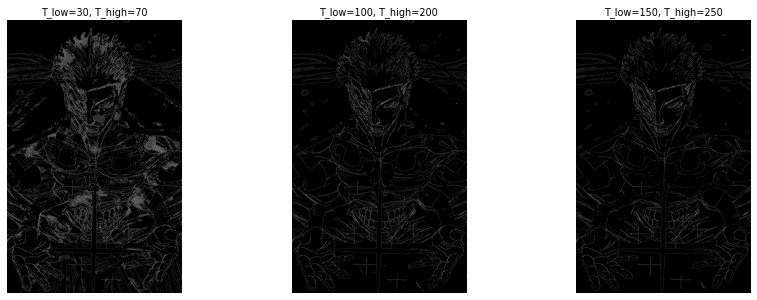

Low thresholds -> many edges + noise. High thresholds -> clean but may lose real edges.


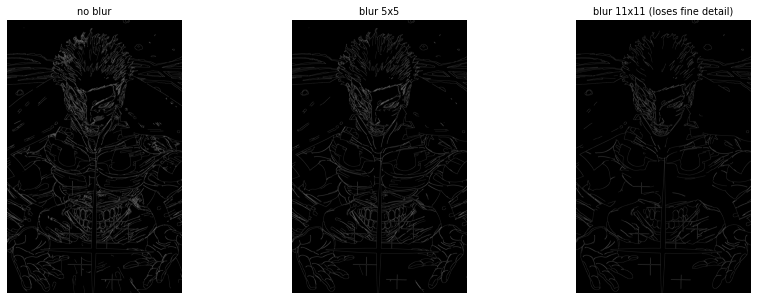

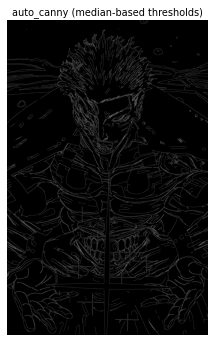

In [58]:
# ---------- Effect of the thresholds (the manual: "often requires experimentation") ----------
settings = [(30, 70), (100, 200), (150, 250)]
show([cv2.Canny(gray, lo, hi) for lo, hi in settings], [f'T_low={lo}, T_high={hi}' for lo, hi in settings], cols=3)
print("Low thresholds -> many edges + noise. High thresholds -> clean but may lose real edges.")

# ---------- Effect of the Gaussian blur before Canny ----------
show([cv2.Canny(gray if k == 1 else cv2.GaussianBlur(gray, (k, k), 0), 50, 150) for k in (1, 5, 11)],
     ['no blur', 'blur 5x5', 'blur 11x11 (loses fine detail)'], cols=3)

# ---------- Picking thresholds automatically from the image's median intensity (a common heuristic) ----------
def auto_canny(img, sigma=0.33):
    v = np.median(img)
    return cv2.Canny(img, int(max(0, (1 - sigma) * v)), int(min(255, (1 + sigma) * v)))

show([auto_canny(smooth)], ['auto_canny (median-based thresholds)'], cols=1, figsize=(5, 5))

---
## Which tool for which job

| Problem | Reach for | Why |
|---|---|---|
| Straighten a tilted scan | Rotation (A2) | one angle fixes it |
| Flatten a photographed page / plate | Perspective (A6) | the camera viewpoint caused the distortion |
| Align two scans of the same object | Rigid (A5) or Affine (A7) | object only moved; no reshaping |
| Feed images to a CNN | Scaling (A3) with `INTER_AREA`/`CUBIC` | fixed input size |
| Detect people or objects by shape | HOG (B1) | edge-direction layout survives colour changes |
| Classify a surface (wood/metal/fabric) | LBP (B2) + energy/contrast (B6) | texture is the signal |
| Find images with similar colours | HSV colour histogram (B3) | global, cheap, `compareHist` |
| Orientation of structure in an image | HED / HIG (B4, B5) | 8 or 9 numbers summarise it |
| Remove noise before further processing | Gaussian blur (B8) | smooth, no blockiness |
| Get clean outlines | Canny (B11) | thin, connected edges |
| Downsample while filtering | Convolution with stride (B9) | how CNN layers shrink maps |

## Errors found in the manual's code (all tested)
| Where | Problem | Effect |
|---|---|---|
| 3.4 HED | `arctan2` gives -180…180 but histogram range is 0…360; histogram built from all pixels, not edges | every negative-angle pixel dropped; flat areas pollute the counts |
| 3.5 HIG | same range problem with `(0, 180)`; `magnitude` computed but unused | negative angles dropped; weak noise counts as much as strong edges |
| 3.6 Texture | `image ** 2` on `uint8` overflows; "contrast" computed as a local sum, not std-dev | wrong energy values; contrast map is not contrast |
| 4 Gaussian blur | `getGaussianKernel` returns a 1-D (5×1) kernel | blur only in the vertical direction |
| 4.2.1.1 | called "full" convolution | `filter2D` returns same-size output (it is not full) |
| 4.2.1.2 / 4.2.1.3 | border types swapped (`BORDER_CONSTANT` is zero padding; `filter2D` has no valid mode) | "valid" example returns a same-size image |
| 4.2.1.4 | `filter2D(..., strides=...)` | `strides` is not a parameter, so it raises an error |
| 5.1 / 5.2 / 3.4 | `cv2.imshow` / `waitKey` in a notebook | freezes Jupyter and Colab; use Matplotlib |
| 1 Objectives | lists "Corner Detection", but the manual has no corner-detection section | nothing to port; Harris/Shi-Tomasi would be the usual content |

*Sources: Lab 04 Manual, Geometric Transformations notebook (AI-4002, FAST-NUCES Karachi).*